In [1]:
#setup
%load_ext autoreload
%autoreload 2

from datetime import date
from datetime import datetime
import matplotlib.pyplot as plt
import netCDF4 as nc
import os
import pandas as pd
import sys
import time
import fiona
import xarray as xr

sys.path.append('D:\\repos\\E-OBS-SWB2\\Python')

from EOBSobject import EOBSobject
from RechargeCalc import RechargeCalc

In [2]:
cwd = 'D:/Dati pesanti/SWB2_MODELMI19'
cwd

'D:/Dati pesanti/SWB2_MODELMI19'

## Use EOBSobject

In [10]:
outpath = os.path.join(cwd, 'climate_ncfile')
inpath = os.path.join(cwd, 'data_original', 'E-OBS')

In [11]:
vars = ['rr', 'tn', 'tx']
outnames = ['prcp', 'tmin', 'tmax']

coord = {'lon': [8.691, 8.929, 9.524, 9.537],
            'lat': [45.611, 45.308, 45.610, 45.306]}
coord = pd.DataFrame(coord)
# need one file per year
start = 2018
end = 2019

In [12]:
for i, var in enumerate(vars):
    f = EOBSobject(var, inpath, outpath, folder = True, swb2 = True)
    f.load()
    # cut in space and time
    f.set_outname(outnames[i])
    f.cut_spacetime(coord, start, end, option = 'singleyear', contourcell=2, autosave = True)
    f.close_netcdf()

In [51]:
var = 'rr'
f = EOBSobject(var, inpath, outpath, folder = True, swb2 = True)
f.load()
# cut in space and time
# f.set_outname(outnames[i])
# f.cut_spacetime(coord, start, end, option = 'singleyear', contourcell=2, autosave = True)
# f.close_netcdf()

In [55]:
SP1 = 90   #days, 01/01 - 30/03
SP2 = 76   #days, 01/04 - 12/06
SP3 = 92   #days, 13/06 - 15/09
SP4 = 107  #days, 16/09 - 31/12
SPs = [SP1, SP2, SP3, SP4]
test = f.SP_sum(method='cut_spacetime', SPs=SPs, coord = coord, start = start, end = end,
               loncol = 'lon', latcol = 'lat', contourcell = 2, option = 'bundle', export = False)

2018 1
2018 2
2018 3
2018 4
2019 1
2019 2
2019 3
2019 4


In [60]:
np.sum(test, axis = 0)*0.6

array([[299.94   , 305.16   , 317.27997, 320.2201 , 322.98004, 320.34003,
        319.02002, 307.80002, 294.18002, 293.52   , 291.72003, 284.82   ],
       [300.     , 311.76004, 321.12003, 327.42   , 331.49997, 326.81998,
        320.64008, 312.96008, 306.71997, 292.74002, 291.78003, 284.33997],
       [306.12   , 318.06   , 328.02005, 330.47998, 332.03998, 331.20004,
        327.78003, 323.81998, 302.94003, 291.48   , 287.58   , 280.98   ],
       [315.90012, 321.30005, 324.66   , 334.02002, 339.0001 , 340.02005,
        336.36   , 329.21997, 317.88   , 300.00003, 289.26   , 283.86   ],
       [325.62003, 327.48   , 338.81995, 348.90002, 353.16006, 353.22006,
        347.1    , 340.62   , 334.67996, 310.14   , 293.34006, 287.1    ],
       [330.36005, 343.55997, 363.12   , 372.30002, 377.64   , 372.47998,
        368.58002, 356.40002, 344.76004, 327.12003, 308.34006, 290.58002],
       [339.48   , 363.41998, 379.86008, 397.20004, 400.38004, 393.00003,
        389.34003, 376.19998, 35

In [ ]:
np.sum(test, axis = 0) #2018 4

array([[277.     , 275.1    , 268.40002, 262.90005, 251.00002, 243.79999,
        228.09999, 225.8    , 216.1    , 211.10002, 217.99998, 229.2    ],
       [285.     , 281.2    , 281.6    , 271.89996, 259.6    , 252.50002,
        236.7    , 235.10002, 225.79999, 225.6    , 231.50003, 240.80002],
       [291.99997, 289.19998, 283.89996, 282.4    , 273.9    , 268.89993,
        263.70004, 255.49998, 249.40002, 243.70003, 243.79997, 250.6    ],
       [300.09998, 304.69995, 304.30002, 298.1    , 292.59998, 286.4    ,
        267.90002, 267.60004, 266.7    , 259.19998, 253.90001, 260.40002],
       [314.99997, 321.39996, 325.9    , 329.69998, 324.69998, 300.49997,
        295.89996, 286.40002, 278.3    , 281.09998, 278.4    , 277.09998],
       [351.20004, 350.40002, 360.8    , 359.10007, 357.4    , 346.80002,
        323.6    , 311.2    , 299.4    , 297.7    , 291.30002, 289.80002],
       [351.59998, 380.69998, 399.09998, 399.50006, 398.00003, 382.39996,
        370.90002, 341.6    , 33

In [46]:
test

In [29]:
f.close_netcdf()

### Cut the result in time

In [ ]:
# load swb2 output and cut it
# from jan 2019 to dec 2019
# and in the MAURICE area
# swb2path = os.path.join(cwd, 'output', 'ModelMI_net_infiltration__2019-01-01_2019-12-31__338_by_660.nc')
swb2path = os.path.join(cwd, 'output', 'ModelMI_net_infiltration__2018-01-01_2019-12-31__338_by_660.nc')
outswb2 = xr.open_dataset(swb2path, engine='netcdf4')

In [14]:
outswb2

<xarray.Dataset> Size: 329MB
Dimensions:           (time: 365, y: 338, x: 660)
Coordinates:
  * time              (time) datetime64[ns] 3kB 2019-01-01 ... 2019-12-31
  * y                 (y) float64 3kB 5.051e+06 5.051e+06 ... 5.017e+06
  * x                 (x) float64 5kB 1.476e+06 1.476e+06 ... 1.542e+06
    lat               (y, x) float64 2MB ...
    lon               (y, x) float64 2MB ...
Data variables:
    net_infiltration  (time, y, x) float32 326MB ...
    crs               int32 4B ...
Attributes:
    source:              net_infiltration output from SWB run started on Jul ...
    executable_version:  version 2.0 Beta, Git branch:  master, Git commit ha...
    conventions:         CF-1.6
    history:             Jul 03 2025 16:00:07: Soil-Water-Balance run started.

In [7]:
datetime(2019,1,1) - datetime(2020, 12, 31)

datetime.timedelta(days=-730)

In [13]:
cut = outswb2.isel(time=slice(0, 730+1)).copy()

In [14]:
cut

<xarray.Dataset> Size: 656MB
Dimensions:           (time: 731, y: 338, x: 660)
Coordinates:
  * time              (time) datetime64[ns] 6kB 2019-01-01 ... 2020-12-31
  * y                 (y) float64 3kB 5.051e+06 5.051e+06 ... 5.017e+06
  * x                 (x) float64 5kB 1.476e+06 1.476e+06 ... 1.542e+06
    lat               (y, x) float64 2MB ...
    lon               (y, x) float64 2MB ...
Data variables:
    net_infiltration  (time, y, x) float32 652MB ...
    crs               int32 4B ...
Attributes:
    source:              net_infiltration output from SWB run started on May ...
    executable_version:  version 2.0 Beta, Git branch:  master, Git commit ha...
    conventions:         CF-1.6
    history:             May 14 2025 16:35:16: Soil-Water-Balance run started.

In [15]:
cut.to_netcdf(os.path.join(cwd, 'output', 'ModelMI_net_infiltration__2019-01-01_2020-12-31__338_by_660.nc'))

In [22]:
check = xr.load_dataset(os.path.join(cwd, 'output', 'ModelMI_net_infiltration__2019-01-01_2019-12-31__338_by_660.nc'), format = 'netcdf4')

## Use RechargeCalc

In [ ]:
start = time.time()

cell_area = 100*100 #m2
#Path to the SWB2 output
swb2path = os.path.join(os.path.join(cwd, 'output','ModelMI_net_infiltration__2018-01-01_2019-12-31__338_by_660.nc'))
#Path to the input .csv files folder
inputpath = os.path.join(cwd,'data_original', 'file_input_rechargecalc', 'swb_MODELMI19')
sppath = os.path.join(inputpath, 'rirrigua_speciale_swb_MODELMI19.csv')

r = RechargeCalc(cell_area, uniqueid = 'indicatore', nSP = 8)
r.load_inputfiles(swb2path, inputpath)

SP1 = 90   #days, 01/01 - 30/03
SP2 = 76   #days, 01/04 - 12/06
SP3 = 92   #days, 13/06 - 15/09
SP4 = 107  #days, 16/09 - 31/12
SPs = [SP1, SP2, SP3, SP4]

r.meteoricR(SPs, units = 'ms', fixrow=1, fixcol=4)

coeffs = {
    'E': 0.3,  #Irrigation technique efficiency
    'R': 0.05, #Residual runoff
    'RISP': 1, #1 - fraction of water saved by a change of irrigation technique
    'P': 1     #Percentage of the cell covered by the irrigation
    }

col = ['land_cover', 'land_cover', 'zona_urbana']
valcol = [123, 124, 1]
option = [0, 1] #0: OR, 1: AND

r.urbanR(coeff=0.125, col=col, valcol=valcol, option=option)

r.irrigationR(coeffs, specialpath=sppath)

r.totalR(fillna=True)

# r.export('recharge','rtot',
#              outpath = os.path.join(cwd, 'rtot'),
#              outname = 'rtot_swb_MODELMI19_v2',
#              withcoord=True,
#              coordpath = os.path.join(inputpath, 'coord.csv'))
# r.georef('recharge','rtot',
#             outpath = os.path.join(cwd, 'rtot'),
#             fname = 'rtot_swb_MODELMI19_v2.shp', 
#             coordpath = os.path.join(inputpath, 'coord.csv'),
#             crs = 'epsg:3003', dropcoord=False, driver = 'ESRI Shapefile')
# end = time.time()
# print((end - start)/60, 'min')

Loading the input files
-----------------------
indicatori file found
ricarica_irrigua file found
extractions file found
Meteoric recharge dataframe creation
------------------------------------
Performing the sum of net_infiltration over the stress periods provided
Output unit measure: ms
End of the procedure
Elapsed time: 4.25 s
Urban recharge dataframe creation
---------------------------------
Replicating columns to create a dataframe of 8 SPs
Elapsed time: 6.37 s
Irrigation recharge dataframe creation
--------------------------------------
Replicating columns to create a dataframe of 8 SPs
Elapsed time: 0.88 s
Total recharge dataframe creation
---------------------------------
rmeteo :  38.42218301782992
rirr :  54.06051894645799
rurb :  7.517298035712101
Elapsed time: 0.68 s


NameError: name 'end' is not defined

In [8]:
r.get_df('recharge', 'rtot').iloc[:, 3:].sum()

SP1    0.001644
SP2    0.004585
SP3    0.004291
SP4    0.002092
SP5    0.000708
SP6    0.004657
SP7    0.004333
SP8    0.004729
dtype: float64

In [23]:
import geopandas as gpd

In [25]:
rtot = gpd.read_file('D:\\Dati pesanti\\SWB2_MODELMI19\\rtot\\rtot_swb_MODELMI19_v2.shp')

In [27]:
rtot.drop(columns = ['SP1', 'SP2', 'SP3', 'SP4'], inplace=True)
rtot.rename(columns = {'SP5': 'SP1',
                       'SP6': 'SP2',
                       'SP7': 'SP3',
                       'SP8': 'SP4'}, inplace=True)

In [29]:
rtot.to_file('D:\\Dati pesanti\\SWB2_MODELMI19\\rtot\\rtot_swb_MODELMI19_v2.shp')

## Confronto dati E-OBS e dati stazioni meteo

In [ ]:
os.path.join(cwd, 'data_original', 'E-OBS', 'rr_ens_mean_0.1deg_reg_v25.0e.nc')

'D:/Dati pesanti/SWB2_MODELMI19\\data_original\\E-OBS\\rr_ens_mean_0.1deg_reg_v25.0e.nc'

In [7]:
f = EOBSobject('rr', os.path.join(cwd, 'data_original', 'E-OBS', 'rr_ens_mean_0.1deg_reg_v25.0e.nc'))

In [8]:
f.load()

In [57]:
f.netcdf['rr']

<class 'netCDF4.Variable'>
int16 rr(time, latitude, longitude)
    units: mm
    _FillValue: -9999
    long_name: rainfall
    scale_factor: 0.1
    add_offset: 0.0
    standard_name: thickness_of_rainfall_amount
    cell_methods: time: mean
unlimited dimensions: time
current shape = (26298, 465, 705)
filling on

In [62]:
f.netcdf['latitude'][45.4967867]

masked_array(data=29.54986054,
             mask=False,
       fill_value=1e+20)

In [13]:
rr = xr.open_dataset(os.path.join(cwd, 'data_original', 'E-OBS', 'rr_ens_mean_0.1deg_reg_v25.0e.nc'))

In [6]:
stations = {
    'Milano_Lambrate': (45.4967867,9.2574811), #lat lon
    'Sant_Angelo_Lodigiano': (45.26063,9.37966),
}

In [ ]:
dfs = {}
for station in stations.keys():
    test = rr.sel(latitude =stations[station][0], longitude=stations[station][1], method = 'nearest')
    dfs[station] = test.to_dataframe()

<Axes: xlabel='time'>

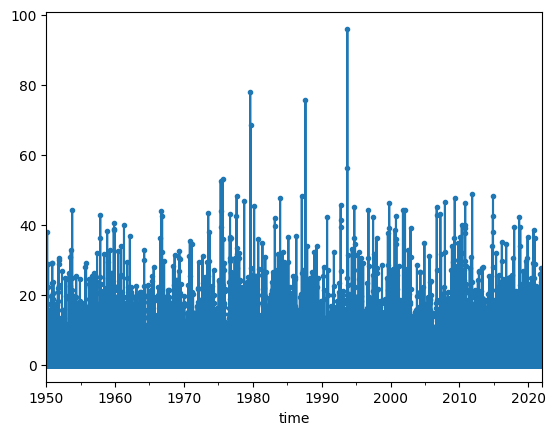

In [35]:
dfs['Sant_Angelo_Lodigiano'].rr.plot(marker = '.')

In [ ]:
#load station data and do the same plot
stat = pd.read_csv(os.path.join(cwd, 'data_original', 'stations', 'merged-prec-daily-clean.csv'))
stat.set_index('Data', inplace = True)
stat.index = pd.to_datetime(stat.index)
sel = ['2006', '2129']

<Axes: xlabel='Data'>

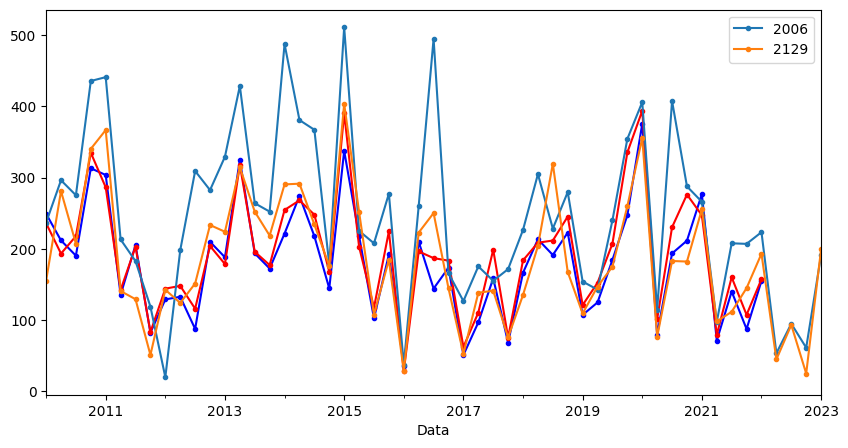

In [67]:
fig, ax = plt.subplots(1,1,figsize=(10,5))
dfs['Sant_Angelo_Lodigiano'].resample('3ME').sum().loc['2010-01-01':, 'rr'].plot(marker='.', ax = ax, color = 'b')
dfs['Milano_Lambrate'].resample('3ME').sum().loc['2010-01-01':, 'rr'].plot(marker='.', ax = ax, color = 'r')
stat[sel].resample('3ME').sum().loc['2010-01-01':, ].plot(marker = '.', ax= ax)

In [69]:
stat[sel].resample('1YE').sum().loc['2010-01-01':, ]

,2006,2129
Data,,
2010-12-31,1467.2,1226.4
2011-12-31,548.8,477.8
2012-12-31,1061.0,685.6
2013-12-31,1249.6,966.2
2014-12-31,1639.0,1257.6
2015-12-31,778.6,576.8
2016-12-31,1069.8,690.0
2017-12-31,683.0,466.8
2018-12-31,1000.6,817.8


In [3]:
tn = xr.open_dataset(os.path.join(cwd, 'data_original', 'E-OBS', 'tn_ens_mean_0.1deg_reg_2011-2024_v31.0e.nc'))

In [7]:
tns = {}
for station in stations.keys():
    test = tn.sel(latitude =stations[station][0], longitude=stations[station][1], method = 'nearest')
    tns[station] = test.to_dataframe()

In [9]:
tns['Milano_Lambrate'].resample('3ME').mean()

,longitude,latitude,tn
time,,,
2011-01-31,9.24986,45.449861,-0.526129
2011-04-30,9.24986,45.449861,5.283034
2011-07-31,9.24986,45.449861,15.918369
2011-10-31,9.24986,45.449861,15.041521
2012-01-31,9.24986,45.449861,1.780217
2012-04-30,9.24986,45.449861,3.846000
2012-07-31,9.24986,45.449861,16.139565
2012-10-31,9.24986,45.449861,14.941739
2013-01-31,9.24986,45.449861,2.033587
